#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [27]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving Assignment 2 dataset (1).csv to Assignment 2 dataset (1) (1).csv


,Column 1,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12-27-2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12-20-2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12-13-2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12-6-2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11-29-2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

In [28]:
duplicates = df.duplicated().sum()
print(duplicates)
missing_values = df.isna().sum()
print(missing_values)

2
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64


1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).

In [5]:
duplicates = df.duplicated().sum()
print(duplicates)
missing_values = df.isna().sum()
print(missing_values)

2
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags      1
Small Bags      2
Large Bags      2
XLarge Bags     1
type            1
year            0
region          0
dtype: int64


1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [29]:
print(df.shape)


(18254, 14)


#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [30]:
if 'Column 1' in df.columns:
    df = df.drop(columns=['Column 1'])
else:
    df = df.iloc[:,1:]

df['year'] = df['year'].astype('category')

2.2 Check for duplicate values and remove them.

In [32]:
df = df.drop_duplicates()

2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [33]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


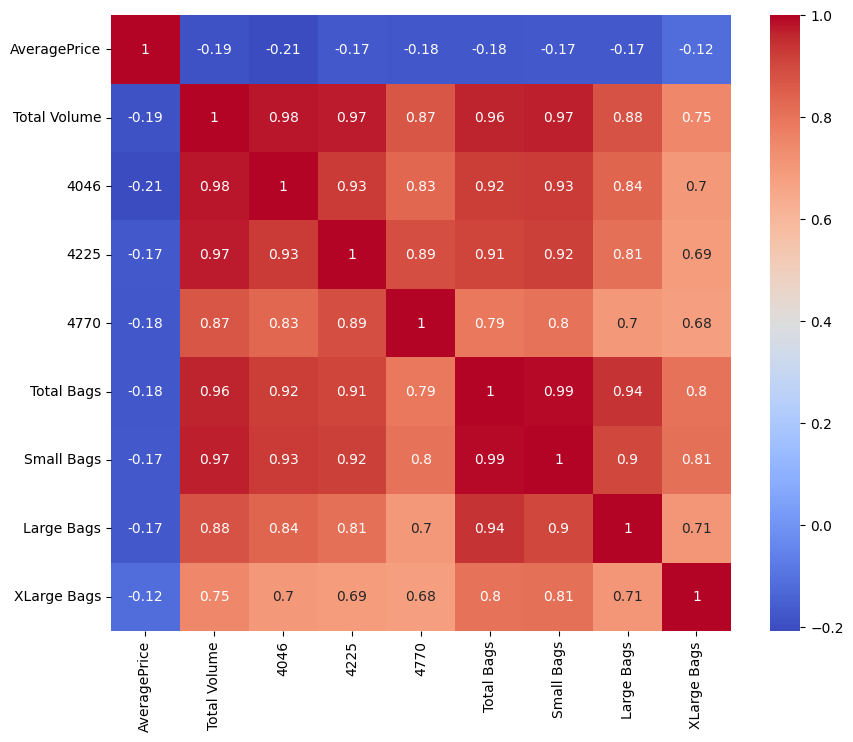

              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192780 -0.208335 -0.172958 -0.179469   
Total Volume     -0.192780      1.000000  0.977863  0.974181  0.872204   
4046             -0.208335      0.977863  1.000000  0.926111  0.833390   
4225             -0.172958      0.974181  0.926111  1.000000  0.887856   
4770             -0.179469      0.872204  0.833390  0.887856  1.000000   
Total Bags       -0.177116      0.963048  0.920057  0.905789  0.792316   
Small Bags       -0.174751      0.967239  0.925281  0.916032  0.802734   
Large Bags       -0.172960      0.880641  0.838646  0.810017  0.698473   
XLarge Bags      -0.117615      0.747159  0.699379  0.688811  0.679864   

              Total Bags  Small Bags  Large Bags  XLarge Bags  
AveragePrice   -0.177116   -0.174751   -0.172960    -0.117615  
Total Volume    0.963048    0.967239    0.880641     0.747159  
4046            0.920057    0.925281    0.838646     0.699379  
422

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
print(corr)

#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

In [34]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    print(col, "min:", df[col].min(), "max:", df[col].max(), "mean:", df[col].mean(), "median:", df[col].median())

cat_cols = df.select_dtypes(include=['object','category']).columns
for col in cat_cols:
    print(col, "unique values:", df[col].unique())

AveragePrice min: 0.44 max: 3.25 mean: 1.4060322156476002 median: 1.37
Total Volume min: 84.56 max: 62505646.52 mean: 850511.5933842867 median: 107354.25
4046 min: 0.0 max: 22743616.17 mean: 292961.2764398422 median: 8643.2
4225 min: 0.0 max: 20470572.61 mean: 295107.96948005696 median: 29056.73
4770 min: 0.0 max: 2546439.11 mean: 22836.031944992326 median: 184.99
Total Bags min: 0.0 max: 19373134.37 mean: 239603.0131421214 median: 39738.53
Small Bags min: 0.0 max: 13384586.8 mean: 182168.14006903354 median: 26351.614999999998
Large Bags min: 0.0 max: 5719096.61 mean: 54329.449232960775 median: 2647.27
XLarge Bags min: 0.0 max: 551693.65 mean: 3105.915917707648 median: 0.0
Date unique values: ['12-27-2015' '12-20-2015' '12-13-2015' '12-6-2015' '11-29-2015'
 '11-22-2015' '11-15-2015' '11-8-2015' '11-1-2015' '10-25-2015'
 '10-18-2015' '10-11-2015' '10-4-2015' '9-27-2015' '9-20-2015' '9-13-2015'
 '9-6-2015' '8-30-2015' '8-23-2015' '8-16-2015' '8-9-2015' '8-2-2015'
 '7-26-2015' '7-19-2015'

3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [35]:
date_cols = [col for col in df.columns if 'date' in col.lower()]
if len(date_cols) > 0:
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    earliest_date = df[date_col].min()
    print("Earliest date:", earliest_date)
    print(df[df[date_col] <= '2010-12-31'])
else:
    earliest_year = df['year'].astype(int).min()
    print("No date column found. Earliest year:", earliest_year)

Earliest date: 1904-01-21 00:00:00
            Date  AveragePrice  Total Volume     4046     4225    4770  \
18250 1904-01-21          1.87      13766.76  1191.92  2452.79  727.94   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18250     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18250  WestTexNewMexico  


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [36]:
max_price = df['AveragePrice'].max()
region_max_price = df[df['AveragePrice'] == max_price]['region'].values
print(max_price)
print(region_max_price)

3.25
['SanFrancisco']


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [26]:
max_volume = df['Total Volume'].max()
region_max_volume = df[df['Total Volume'] == max_volume]['region'].values
print(max_volume)
print(region_max_volume)

62505646.52
['TotalUS']
